In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import pandas as pd
import numpy as np
import json
import time
from pathlib import Path
from src.models.embedding_retriever import EmbeddingRetriever
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Метрики для оценки моделей
def recall_at_k(retrieved_ids: List, relevant_ids: Set, k: int) -> float:
    if not relevant_ids: return 0.0
    return len(set(retrieved_ids[:k]) & relevant_ids) / len(relevant_ids)

def precision_at_k(retrieved_ids: List, relevant_ids: Set, k: int) -> float:
    return len(set(retrieved_ids[:k]) & relevant_ids) / k

def reciprocal_rank(retrieved_ids: List, relevant_ids: Set) -> float:
    for i, rid in enumerate(retrieved_ids):
        if rid in relevant_ids: return 1.0 / (i + 1)
    return 0.0

def dcg_at_k(scores: List[float], k: int) -> float:
    return sum(s / np.log2(i + 2) for i, s in enumerate(scores[:k]))

def ndcg_at_k(retrieved_ids: List, retrieved_scores: List[float], relevant_ids: Set, k: int) -> float:
    ideal = sorted([1.0 if rid in relevant_ids else 0.0 for rid in retrieved_ids], reverse=True)
    idcg = dcg_at_k(ideal, k)
    if idcg == 0: return 0.0
    actual = [1.0 if rid in relevant_ids else 0.0 for rid in retrieved_ids]
    return dcg_at_k(actual, k) / idcg

def evaluate_retriever(retriever, queries: List[str], relevant_docs: List[Set], top_k: int = 10) -> Dict[str, float]:
    recalls, precisions, rrs, ndcgs = [], [], [], []
    for query, relevant in zip(queries, relevant_docs):
        results = retriever.search(query, top_k=top_k)
        rid_list = [rid for rid, _ in results]
        score_list = [s for _, s in results]
        recalls.append(recall_at_k(rid_list, relevant, top_k))
        precisions.append(precision_at_k(rid_list, relevant, top_k))
        rrs.append(reciprocal_rank(rid_list, relevant))
        ndcgs.append(ndcg_at_k(rid_list, score_list, relevant, top_k))
    return {
        'Recall@K': np.mean(recalls),
        'Precision@K': np.mean(precisions),
        'MRR': np.mean(rrs),
        'NDCG@K': np.mean(ndcgs)
    }

In [3]:
recipes = pd.read_parquet('../data/processed/recipes_processed.parquet')
queries_df = pd.read_parquet('../data/processed/training_queries.parquet')

In [4]:
val_size = int(len(queries_df) * 0.2)
val_q = queries_df.iloc[-val_size:]

train_docs = recipes['search_text'].fillna('').tolist()
train_ids = recipes.index.tolist()
val_queries = val_q['query_text'].tolist()
val_relevant = [set([int(row['target_recipe_id'])]) for _, row in val_q.iterrows()]

In [5]:
with open('../artifacts/metrics.json') as f:
    baseline_metrics = json.load(f)

In [6]:
print(f"\n{'='*45}")
print(f"Обучение модели: Embeddings")
print(f"{'='*45}")

t0 = time.time()
emb_model = EmbeddingRetriever(model_name='all-MiniLM-L6-v2', device='cpu')
emb_model.fit(train_docs, train_ids)
fit_time = time.time() - t0

print(f"Время обучения   : {fit_time:.2f} сек")
print(f"Оценка на валидации...")

emb_metrics = evaluate_retriever(emb_model, val_queries, val_relevant, top_k=10)
emb_metrics['fit_time_sec'] = round(fit_time, 2)

print("\n Результаты:")
print(f"Recall@10    : {emb_metrics['Recall@K']:.3f}")
print(f"Precision@10 : {emb_metrics['Precision@K']:.3f}")
print(f"MRR          : {emb_metrics['MRR']:.3f}")
print(f"NDCG@10      : {emb_metrics['NDCG@K']:.3f}")
print(f"Время обучения: {emb_metrics['fit_time_sec']:.2f} сек")
print(f"{'─'*45}\n")


Обучение модели: Embeddings


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Время обучения   : 18.81 сек
Оценка на валидации...

 Результаты:
Recall@10    : 0.900
Precision@10 : 0.090
MRR          : 0.786
NDCG@10      : 0.814
Время обучения: 18.81 сек
─────────────────────────────────────────────



In [7]:
model_path = Path('../artifacts/models/embeddings.pkl')
model_path.parent.mkdir(parents=True, exist_ok=True)
emb_model.save(model_path)
print(f"Модель сохранена: {model_path}")

Модель сохранена: ..\artifacts\models\embeddings.pkl


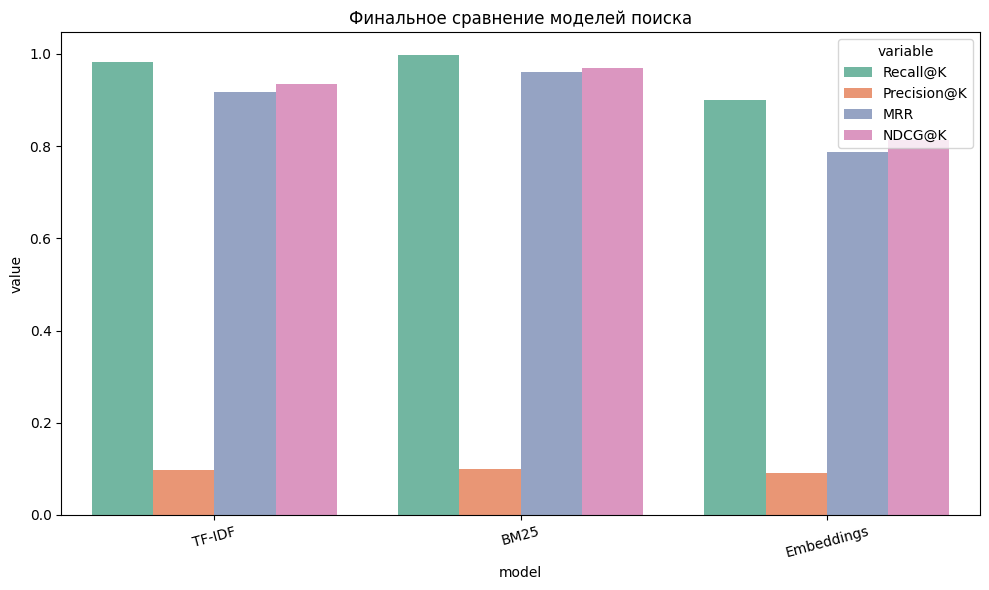


ИТОГОВАЯ СВОДКА ПО МОДЕЛЯМ
Модель       | Recall@10 | Prec@10  | MRR    | NDCG@10  | Время (с)
-----------------------------------------------------------------
TF-IDF       | 0.983     | 0.098    | 0.918  | 0.934    | 0.06     
BM25         | 0.997     | 0.100    | 0.961  | 0.970    | 0.03     
Embeddings   | 0.900     | 0.090    | 0.786  | 0.814    | 18.81    



In [8]:
# Сравнение всех метрик
all_metrics = {**baseline_metrics, 'Embeddings': emb_metrics}
res_df = pd.DataFrame(all_metrics).T
res_df['model'] = res_df.index

# График сравнения
plt.figure(figsize=(10,6))
sns.barplot(data=res_df.melt(id_vars='model', value_vars=['Recall@K', 'Precision@K', 'MRR', 'NDCG@K']), 
            x='model', y='value', hue='variable', palette='Set2')
plt.title('Финальное сравнение моделей поиска')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(f"\nИТОГОВАЯ СВОДКА ПО МОДЕЛЯМ")
print(f"{'='*65}")
print(f"{'Модель':<12} | {'Recall@10':<9} | {'Prec@10':<8} | {'MRR':<6} | {'NDCG@10':<8} | {'Время (с)':<9}")
print(f"{'-'*65}")
for _, row in res_df.iterrows():
    print(f"{row['model']:<12} | {row['Recall@K']:<9.3f} | {row['Precision@K']:<8.3f} | {row['MRR']:<6.3f} | {row['NDCG@K']:<8.3f} | {row['fit_time_sec']:<9.2f}")
print(f"{'='*65}\n")

In [10]:
with open('../artifacts/metrics.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)